### Round 0 Analysis - Davide
Provide an analysis of both products, focusing mainly on TOMATOES since EMERALDS are just Market Making
I'll be adding log prices and log returns to the dataframe, moving on with the modelling of returns and other hypotheses

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera


plt.style.use("dark_background")
sns.set_palette("pastel")

In [ ]:
# CELL FOR THE FUNCTIONS USED LATER ON FOR OTHER THINGS

def load_trading_data(data_folder: str, round: int, days: list[int]) -> dict[str, pd.DataFrame]:
    """
    Load trading data from CSV files into pandas DataFrames.

    Args:
        data_folder (str): Path to the folder containing the CSV files
        round (int): Round to load data for
        days (list): List of days for which data is available

    Returns:
        Dict[str, pd.DataFrame]: Dictionary containing the following DataFrames:
            - 'prices': Price data for all days
            - 'trades': Trade data for all days
    """
    data = {
        'prices': [],
        'trades': [],
        'observations': []
    }

    # Load data for each day
    for day in days:
        # Load price data
        price_file = os.path.join(data_folder, f'prices_round_{round}_day_{day}.csv')
        if os.path.exists(price_file):
            price_df = pd.read_csv(price_file, sep=';')
            # Add day column
            price_df['day'] = day
            # Convert timestamp if it exists
            if 'timestamp' in price_df.columns:
                price_df = price_df.sort_values('timestamp')
            data['prices'].append(price_df)

        # Load trade data
        trade_file = os.path.join(data_folder, f'trades_round_{round}_day_{day}.csv')
        if os.path.exists(trade_file):
            trade_df = pd.read_csv(trade_file, sep=';')
            trade_df['day'] = day
            if 'timestamp' in trade_df.columns:
                trade_df = trade_df.sort_values('timestamp')
            data['trades'].append(trade_df)

        # Load observation data
        observation_file = os.path.join(data_folder, f'observations_round_{round}_day_{day}.csv')
        if os.path.exists(observation_file):
            observation_df = pd.read_csv(observation_file, sep=',')
            observation_df['day'] = day
            if 'timestamp' in observation_df.columns:
                observation_df = observation_df.sort_values('timestamp')
            data['observations'].append(observation_df)

    # Concatenate all days' data
    result = {}
    for key, dfs in data.items():
        if dfs:  # Only add if we found any data
            result[key] = pd.concat(dfs, ignore_index=True)

    return result

def get_product_data(df: pd.DataFrame, product: str) -> pd.DataFrame:
    """
    Filter DataFrame for a specific product.

    Args:
        df (pd.DataFrame): DataFrame containing trading data
        product (str): Product name to filter for

    Returns:
        pd.DataFrame: Filtered DataFrame containing only data for the specified product
    """
    return df[df['product'] == product]

def get_day_data(df: pd.DataFrame, day: int) -> pd.DataFrame:
    """
    Filter DataFrame for a specific day.

    Args:
        df (pd.DataFrame): DataFrame containing trading data
        day (int): Day number to filter for

    Returns:
        pd.DataFrame: Filtered DataFrame containing only data for the specified day
    """
    return df[df['day'] == day]

def get_product_day_data(df: pd.DataFrame, product: str, day: int) -> pd.DataFrame:
    """
    Filter DataFrame for a specific product and day.

    Args:
        df (pd.DataFrame): DataFrame containing trading data
        product (str): Product name to filter for
        day (int): Day number to filter for

    Returns:
        pd.DataFrame: Filtered DataFrame containing only data for the specified product and day
    """
    return df[(df['product'] == product) & (df['day'] == day)]

def get_price_data(df: pd.DataFrame, product: str = None, day: int = None) -> pd.DataFrame:
    """
    Get price data with optional filtering by product and/or day.

    Args:
        df (pd.DataFrame): DataFrame containing price data
        product (str, optional): Product name to filter for
        day (int, optional): Day number to filter for

    Returns:
        pd.DataFrame: Filtered price data
    """
    result = df.copy()
    if product:
        result = result[result['product'] == product]
    if day:
        result = result[result['day'] == day]
    if 'timestamp' in result.columns:
        result = result.sort_values('timestamp')
    return result

def get_order_book_data(df: pd.DataFrame, product: str = None, day: int = None) -> pd.DataFrame:
    """
    Get order book data with optional filtering by product and/or day.

    Args:
        df (pd.DataFrame): DataFrame containing price data
        product (str, optional): Product name to filter for
        day (int, optional): Day number to filter for

    Returns:
        pd.DataFrame: Filtered order book data
    """
    result = df.copy()
    if product:
        result = result[result['product'] == product]
    if day:
        result = result[result['day'] == day]
    if 'timestamp' in result.columns:
        result = result.sort_values('timestamp')
    return result

def get_volume_data(df: pd.DataFrame, product: str = None, day: int = None) -> pd.DataFrame:
    """
    Get volume data with optional filtering by product and/or day.

    Args:
        df (pd.DataFrame): DataFrame containing trade data
        product (str, optional): Product name to filter for
        day (int, optional): Day number to filter for

    Returns:
        pd.DataFrame: Filtered volume data
    """
    result = df.copy()
    if product:
        result = result[result['product'] == product]
    if day:
        result = result[result['day'] == day]
    if 'timestamp' in result.columns:
        result = result.sort_values('timestamp')
    return result

def convert_timestamp(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(t=(df['day'] - 1) * 1_000_000 + df['timestamp']).drop(columns=['day', 'timestamp'])

### Data Loading

In [3]:
REPO_ROOT = os.getcwd()
DATA_FOLDER = f"{REPO_ROOT}/data"
ROUND_NUM = 0
DAYS = [-2, -1]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (40000, 17)
Trades Shape : (1219, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2


### Splitting the datasets based on the products

In [4]:
products = prices_df["product"].unique()

emeralds_prices_df = prices_df[prices_df["product"] == "EMERALDS"]
tomatoes_prices_df = prices_df[prices_df["product"] == "TOMATOES"]
emeralds_trades_df = trades_df[trades_df["symbol"] == "EMERALDS"]
tomatoes_trades_df = trades_df[trades_df["symbol"] == "TOMATOES"]

In [5]:
'''
Here we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
'''
emeralds_trades = emeralds_trades_df.copy()
tomatoes_trades = tomatoes_trades_df.copy()

# Grouping and merging the EMERALDS so we only have 1 dataset containing both prices and trades, sorted by timestamp
emeralds_trades = emeralds_trades.drop(columns = ["buyer", "seller", "currency"])
emeralds_trades = emeralds_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
emeralds_trades = emeralds_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
emeralds = emeralds_prices_df.merge(emeralds_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Grouping and merging the EMERALDS so we only have 1 dataset containing both prices and trades, sorted by timestamp
tomatoes_trades = tomatoes_trades.drop(columns = ["buyer", "seller", "currency"])
tomatoes_trades = tomatoes_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
tomatoes_trades = tomatoes_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
tomatoes = tomatoes_prices_df.merge(tomatoes_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Convert to continuous timeframe so we don't have 2 separate days
emeralds = convert_timestamp(emeralds)
tomatoes = convert_timestamp(tomatoes)

emeralds.head()


,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t
0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0,NaN,NaN,-3000000
1,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,NaN,NaN,-2999900
2,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0,NaN,NaN,-2999800
3,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0,0.0,NaN,NaN,-2999700
4,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0,NaN,NaN,-2999600


# Price and Trades plots

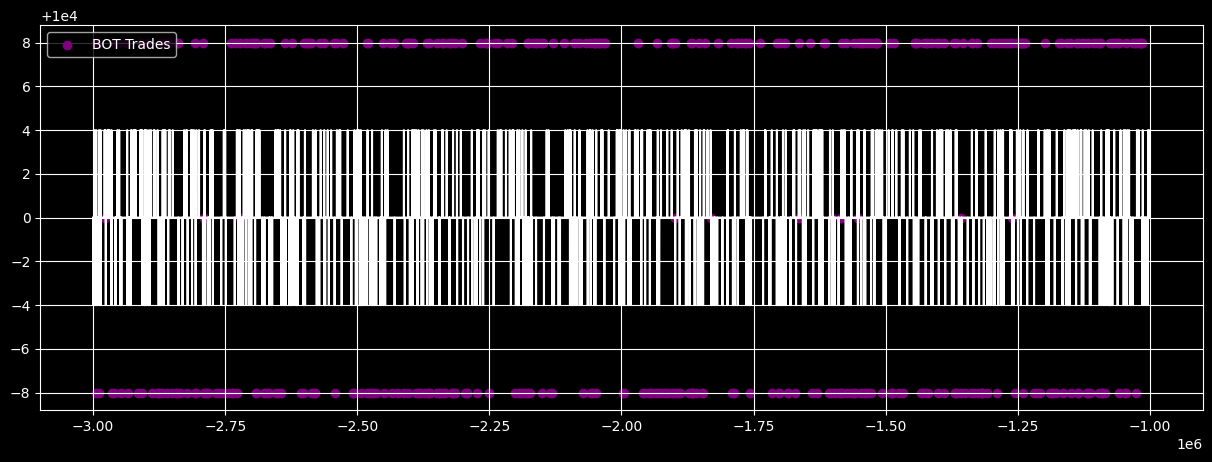

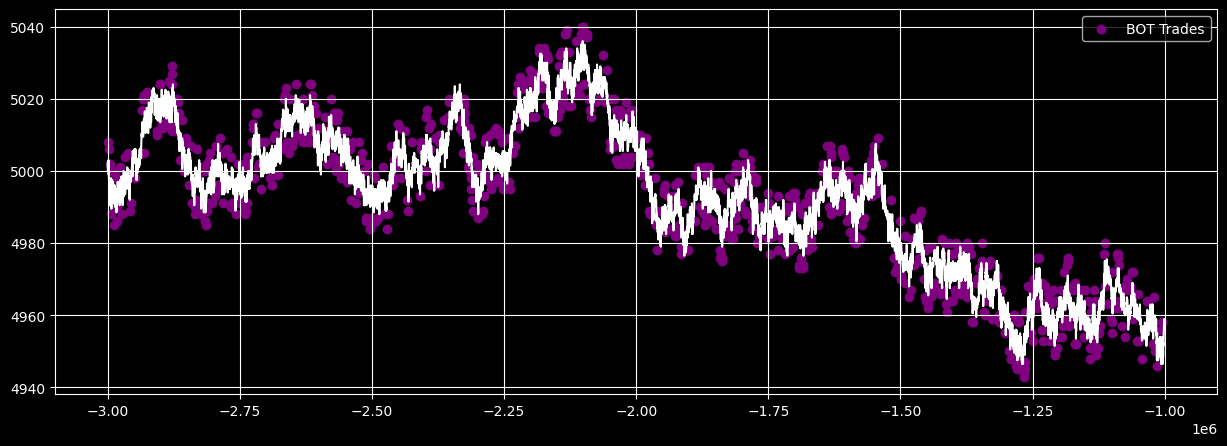

In [6]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(emeralds["t"], emeralds["mid_price"], color = "white")
plt.scatter(emeralds["t"], emeralds["market order price"], color = "purple", label = "BOT Trades")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize = (15,5))
plt.plot(tomatoes["t"], tomatoes["mid_price"], color = "white")
plt.scatter(tomatoes["t"], tomatoes["market order price"], color = "purple", label = "BOT Trades")
plt.grid(True)
plt.legend()
plt.show()

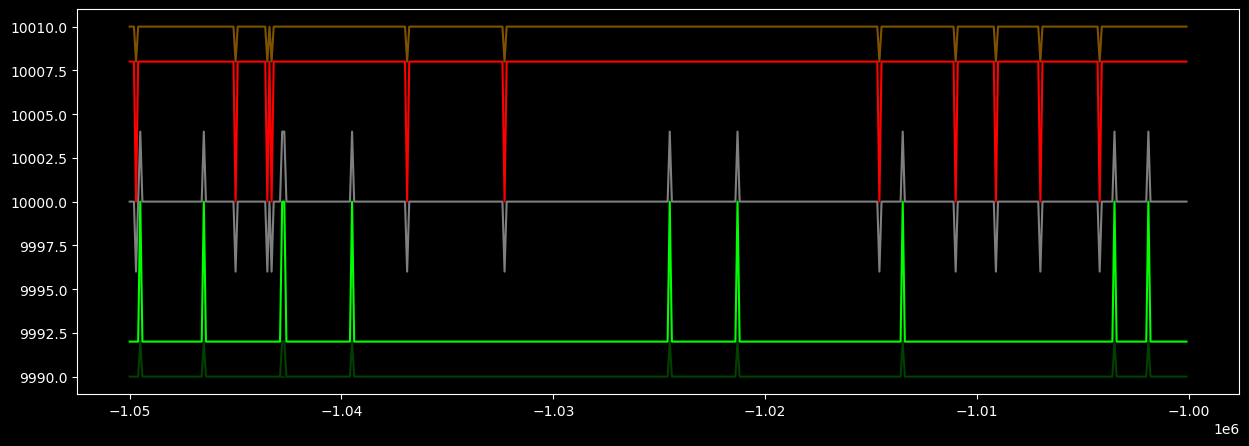

In [7]:
plt.figure(figsize=(15,5))
plt.plot(emeralds["t"][-500:], emeralds["mid_price"][-500:], color = "white", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["ask_price_1"][-500:], color = "red", alpha = 1)
plt.plot(emeralds["t"][-500:], emeralds["ask_price_2"][-500:], color = "orange", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["ask_price_3"][-500:], color = "salmon", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["bid_price_1"][-500:], color = "lime", alpha = 1)
plt.plot(emeralds["t"][-500:], emeralds["bid_price_2"][-500:], color = "green", alpha = 0.5)
plt.plot(emeralds["t"][-500:], emeralds["bid_price_3"][-500:], color = "darkgreen", alpha = 0.5)
plt.show()

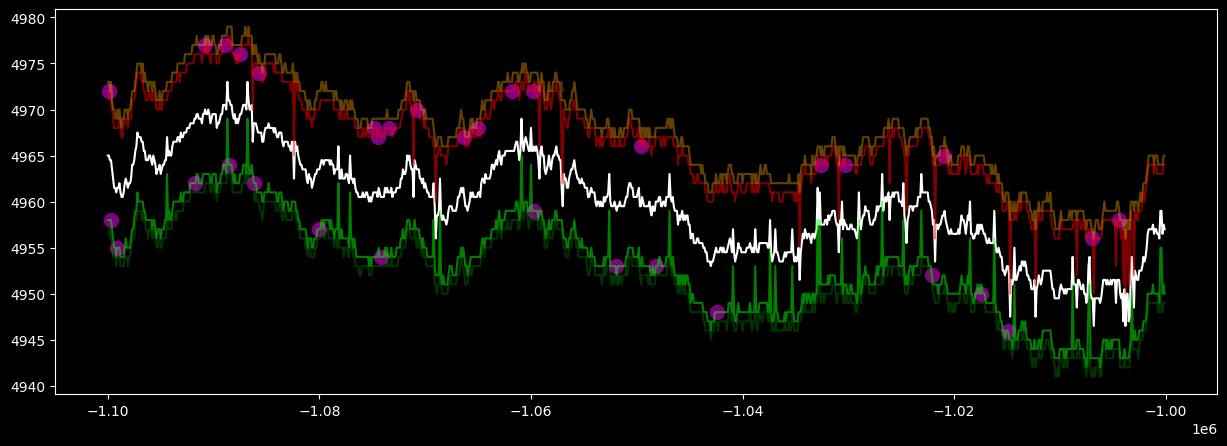

In [8]:
# This considers the mid price
plt.figure(figsize=(15,5))
plt.plot(tomatoes["t"][-1000:], tomatoes["mid_price"][-1000:], color = "white", alpha = 1)
plt.plot(tomatoes["t"][-1000:], tomatoes["ask_price_1"][-1000:], color = "red", alpha = 0.5)
plt.plot(tomatoes["t"][-1000:], tomatoes["ask_price_2"][-1000:], color = "orange", alpha = 0.4)
plt.plot(tomatoes["t"][-1000:], tomatoes["ask_price_3"][-1000:], color = "salmon", alpha = 0.3)
plt.plot(tomatoes["t"][-1000:], tomatoes["bid_price_1"][-1000:], color = "lime", alpha = 0.5)
plt.plot(tomatoes["t"][-1000:], tomatoes["bid_price_2"][-1000:], color = "green", alpha = 0.4)
plt.plot(tomatoes["t"][-1000:], tomatoes["bid_price_3"][-1000:], color = "darkgreen", alpha = 0.4)
plt.scatter(tomatoes["t"][-1000:], tomatoes["market order price"][-1000:], color = "purple", alpha = 1, s = 100)
plt.show()

In [9]:
# This computes the fair value as the mid price between max vol bid and max vol ask
bid_volumes = tomatoes[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].fillna(0)
ask_volumes = tomatoes[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].fillna(0)

bid_prices = np.select(
    [bid_volumes.idxmax(axis=1) == "bid_volume_1",
     bid_volumes.idxmax(axis=1) == "bid_volume_2",
     bid_volumes.idxmax(axis=1) == "bid_volume_3"],
    [tomatoes["bid_price_1"], tomatoes["bid_price_2"], tomatoes["bid_price_3"]]
)
ask_prices = np.select(
    [ask_volumes.idxmax(axis=1) == "ask_volume_1",
     ask_volumes.idxmax(axis=1) == "ask_volume_2",
     ask_volumes.idxmax(axis=1) == "ask_volume_3"],
    [tomatoes["ask_price_1"], tomatoes["ask_price_2"], tomatoes["ask_price_3"]]
)

tomatoes["fv"] = (bid_prices + ask_prices) / 2


### Volatility Arbitrage

In [10]:
tomatoes["log_prices"] = np.log(tomatoes["mid_price"])
tomatoes["log_returns"] = tomatoes["log_prices"] - tomatoes["log_prices"].shift(1)
tomatoes.head()

,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,...,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t,fv,log_prices,log_returns
0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,...,NaN,NaN,5000.0,0.0,NaN,NaN,-3000000,5000.0,8.517193,NaN
1,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,...,NaN,NaN,5002.5,0.0,NaN,NaN,-2999900,5000.0,8.517693,0.0005
2,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,...,NaN,NaN,5001.0,0.0,NaN,NaN,-2999800,5001.0,8.517393,-0.0003
3,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,...,NaN,NaN,5001.5,0.0,NaN,NaN,-2999700,5001.0,8.517493,0.0001
4,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,...,NaN,NaN,5001.5,0.0,NaN,NaN,-2999600,5001.0,8.517493,0.0000


P-Value of ADF Test (H0: Non-Stationarity, H1: Stationarity): 0.0
P-Value of JB Test (H0: Normality, H1: Non-Normality): 0.0


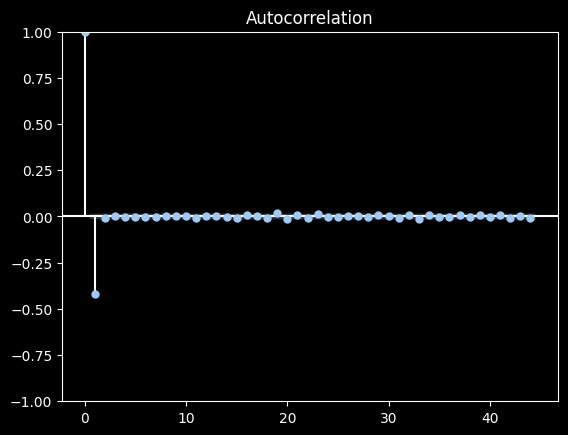

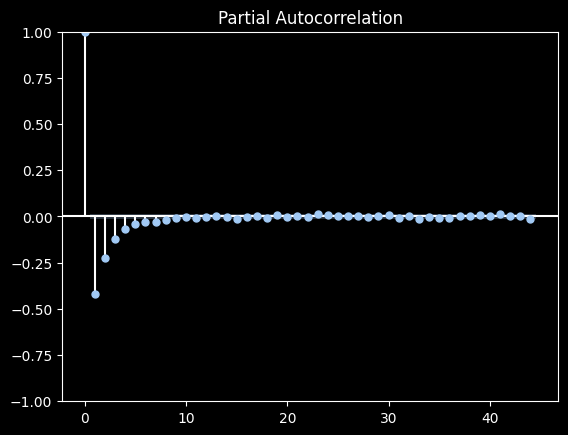

In [11]:
# Log returns are stationary
print(f"P-Value of ADF Test (H0: Non-Stationarity, H1: Stationarity): {adfuller(tomatoes["log_returns"].dropna())[1]:.4}")

# ACF and PACF
plot_acf(tomatoes["log_returns"].dropna())
plot_pacf(tomatoes["log_returns"].dropna())

# Normality
print(f"P-Value of JB Test (H0: Normality, H1: Non-Normality): {jarque_bera(tomatoes["log_returns"].dropna())[1]:.4}")

### Z SCORE ANALYSIS

$z = \frac{x - \mu}{\sigma}$

In [15]:
tomatoes["100_EMA"] = tomatoes["fv"].ewm(span=50, adjust=False).mean()
tomatoes["Z_Score"] = (tomatoes["fv"] - tomatoes["100_EMA"]) / tomatoes["fv"].ewm(span=50, adjust=False).std()
tomatoes.head()

,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,...,mid_price,profit_and_loss,market order price,market order quantity,t,fv,log_prices,log_returns,100_EMA,Z_Score
0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,...,5000.0,0.0,NaN,NaN,-3000000,5000.0,8.517193,NaN,5000.000000,NaN
1,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,...,5002.5,0.0,NaN,NaN,-2999900,5000.0,8.517693,0.0005,5000.000000,NaN
2,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,...,5001.0,0.0,NaN,NaN,-2999800,5001.0,8.517393,-0.0003,5000.039216,1.884268
3,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,...,5001.5,0.0,NaN,NaN,-2999700,5001.0,8.517493,0.0001,5000.076894,1.584487
4,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,...,5001.5,0.0,NaN,NaN,-2999600,5001.0,8.517493,0.0000,5000.113094,1.450823


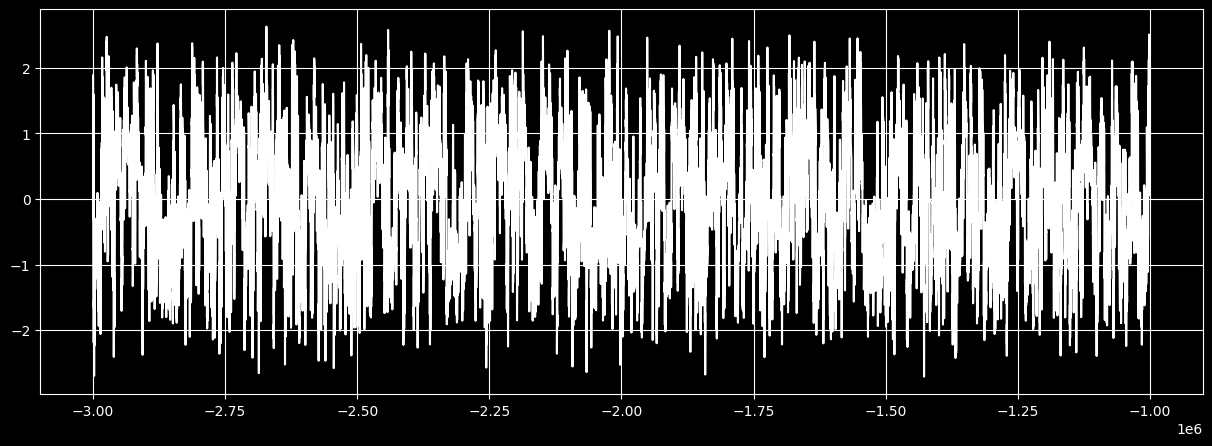

In [16]:
plt.figure(figsize = (15,5))
plt.plot(tomatoes["t"], tomatoes["Z_Score"], color = "white")

plt.grid(True)
plt.show()


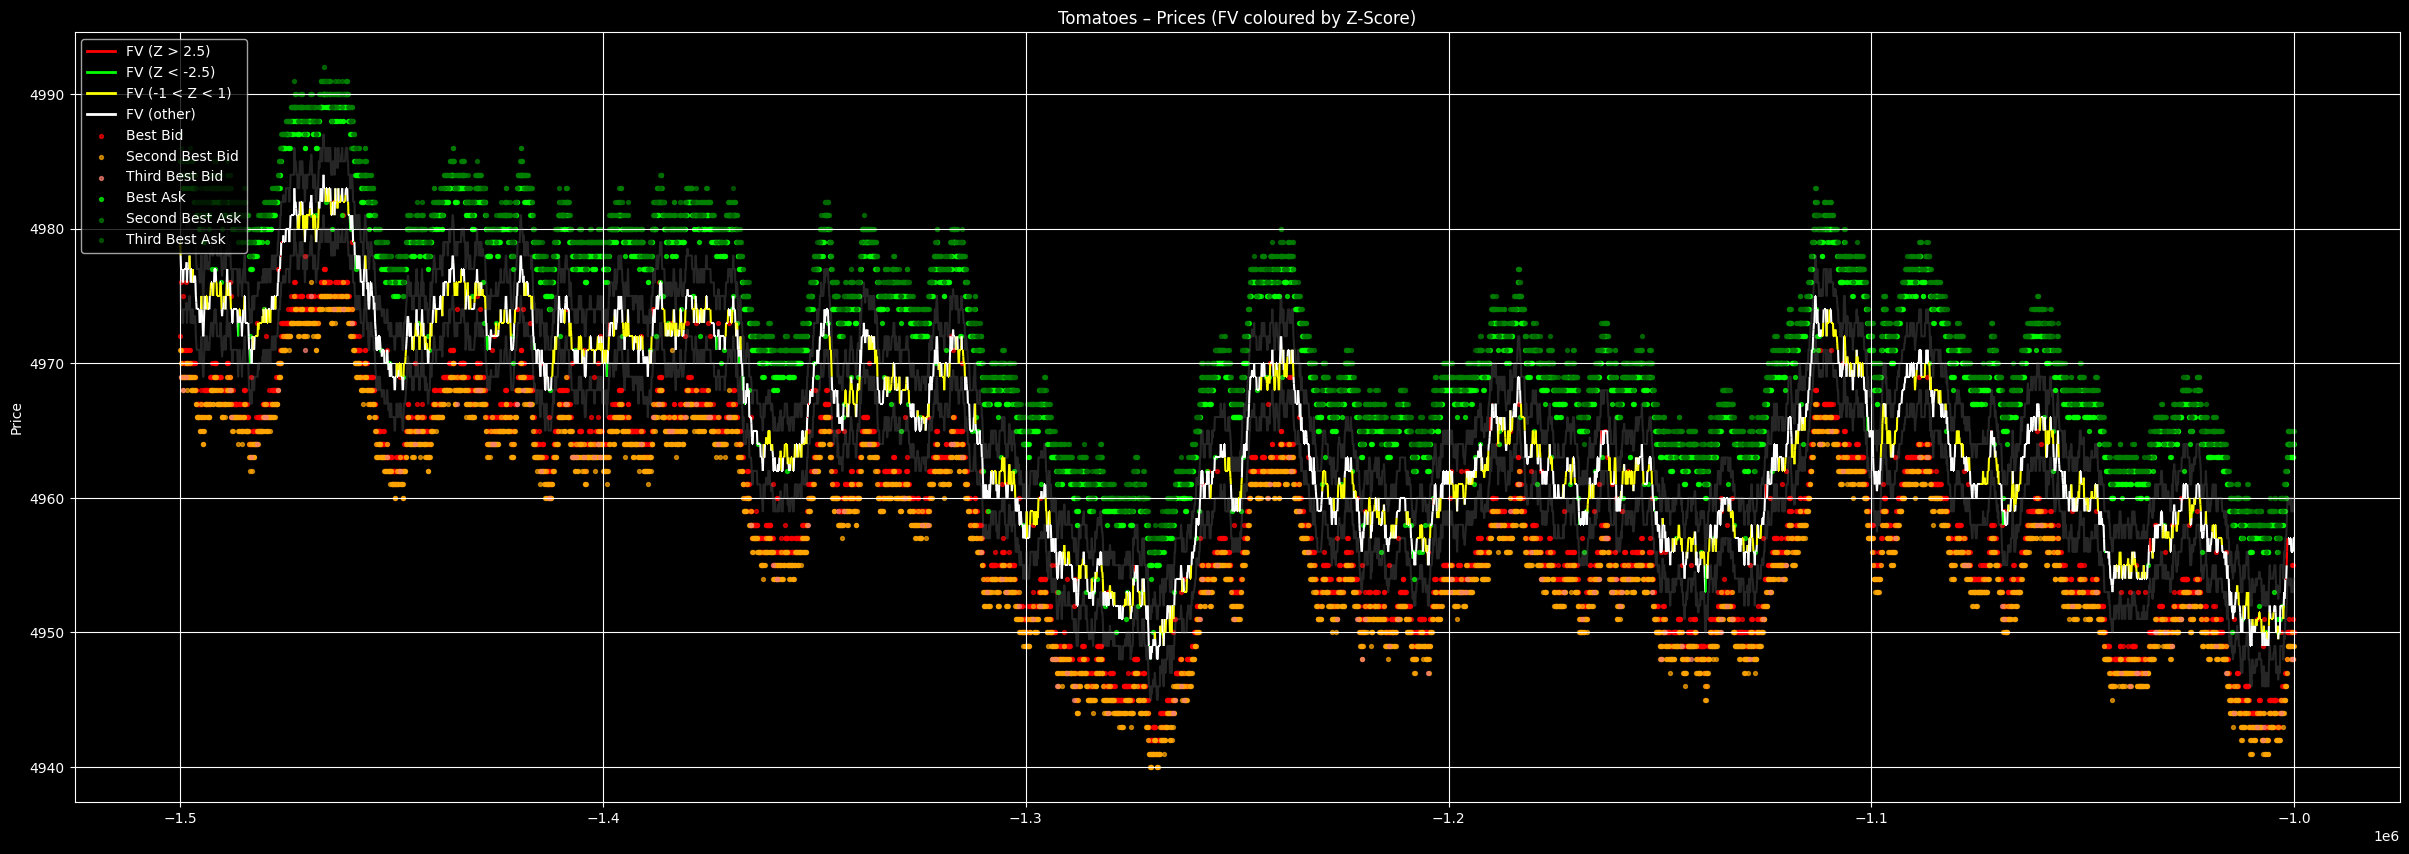

In [18]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(30, 10))

# Slice data
t  = tomatoes["t"][-5000:].values
fv = tomatoes["fv"][-5000:].values
z  = tomatoes["Z_Score"][-5000:].values

# Assign a color to each segment based on Z-score of the start point
def fv_color(zi):
    if np.isnan(zi):
        return "white"
    elif zi > 2:
        return "red"
    elif zi < -2:
        return "lime"
    elif -0.5 <= zi <= 0.5:
        return "yellow"
    else:
        return "white"

seg_colors = [fv_color(z[i]) for i in range(len(z) - 1)]

# Build a LineCollection so each segment can have its own colour
points   = np.array([t, fv]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, colors=seg_colors, linewidth=1.5, zorder=3)
ax1.add_collection(lc)
ax1.autoscale()

# Bid / Ask scatter
ax1.plot(tomatoes["t"][-5000:], tomatoes["fv"][-5000:] - 3, color = "grey", alpha = 0.3)
ax1.plot(tomatoes["t"][-5000:], tomatoes["fv"][-5000:] + 3, color = "grey", alpha = 0.3)
ax1.scatter(tomatoes["t"][-5000:], tomatoes["bid_price_1"][-5000:], color="red",       s=8, alpha=0.7, label="Best Bid")
ax1.scatter(tomatoes["t"][-5000:], tomatoes["bid_price_2"][-5000:], color="orange",    s=8, alpha=0.7, label="Second Best Bid")
ax1.scatter(tomatoes["t"][-5000:], tomatoes["bid_price_3"][-5000:], color="salmon",    s=8, alpha=0.7, label="Third Best Bid")
ax1.scatter(tomatoes["t"][-5000:], tomatoes["ask_price_1"][-5000:], color="lime",      s=8, alpha=0.7, label="Best Ask")
ax1.scatter(tomatoes["t"][-5000:], tomatoes["ask_price_2"][-5000:], color="green",     s=8, alpha=0.7, label="Second Best Ask")
ax1.scatter(tomatoes["t"][-5000:], tomatoes["ask_price_3"][-5000:], color="darkgreen", s=8, alpha=0.7, label="Third Best Ask")

ax1.set_ylabel("Price", color="white")
ax1.tick_params(axis="y", labelcolor="white")

# Legend — proxy artists for the coloured FV segments
fv_legend = [
    Line2D([0], [0], color="red",    linewidth=2, label="FV (Z > 2.5)"),
    Line2D([0], [0], color="lime",   linewidth=2, label="FV (Z < -2.5)"),
    Line2D([0], [0], color="yellow", linewidth=2, label="FV (-1 < Z < 1)"),
    Line2D([0], [0], color="white",  linewidth=2, label="FV (other)"),
]
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(fv_legend + lines1,
           [l.get_label() for l in fv_legend] + labels1,
           loc="upper left")

plt.grid(True)
plt.title("Tomatoes – Prices (FV coloured by Z-Score)")
plt.show()